In [1]:
# Load necessary library
library(fs)
library("ggplot2")
install.packages("tidyverse")
library(dplyr)
library("tidyverse")
# Required library for rolling mean
library(zoo)  # Install if needed: install.packages("zoo")
# Assuming 'dot_plot_data' is wide format, create a heatmap (for a grid of values)
library(reshape2,lib.loc="/data/proj2/home/students/u.srinivasan/R/library")
library(RColorBrewer)


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




load fixed r files

In [2]:
#Define mutation rate and generation time
mu <- 2.45e-10
gen <- 0.16

# Initialize lists to store plot data for each chromosome and "All Chromosome"

plot_data_list_newhetfile_smbc_regions_fixed_r <- list()
plot_data_list_newhetfile_smbc_regions_free_r <- list()
plot_data_list_newhetfile_smbc_regions_free_r_wprior <- list()

# Construct the file paths
filepath_newhetfile_smbc_regions_fixed_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/Maesot/regions/fixed_r/mut_rate_rm10_4.0425e-09/")
filepath_newhetfile_smbc_regions_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_mut_rate_4.0425e-9_broad_priors/")
filepath_newhetfile_smbc_regions_free_r_wprior<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_prior_mut_rate_4.0425e-09/")

# Initialize the list to store data for each chromosome
plot_data_list_newhetfile_smbc_regions_fixed_r <- list()

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 4:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_fixed_r, 
                               pattern = search_pattern_regions, 
                               full.names = TRUE)
    
    # Check if any region files exist for the current chromosome
    if (length(region_files) > 0) {
        # Read and load all region files for the current chromosome
        data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
        plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]] <- data_list_regions
    } else {
        message(paste("SMBC fixed r not found for chromosome", chr))
    }
}



# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 4:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_free_r, pattern = search_pattern_regions, full.names = TRUE)
    print(region_files)
    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_smbc_regions_free_r[[chr]] <- data_list_regions
    }

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_free_r_wprior, pattern = search_pattern_regions, full.names = TRUE)
    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]] <- data_list_regions
    }

filepath_newhetfile_smbc_full_chr <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/Maesot/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/")
filepath_newhetfile_smbc_full_chr_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Full_chr/free_r_mut_rate_4.0425_broader_priors/")
filepath_newhetfile_smbc_full_chr_free_r_wprior<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Full_chr/free_r_prior_mut_rate_4.0425e-09/")

plot_data_list_newhetfile_smbc_full_chr_fixed_r <- list()
plot_data_list_newhetfile_smbc_full_chr_free_r <- list()
plot_data_list_newhetfile_smbc_full_chr_free_r_wprior <- list()


 #Loop over each chromosome to load eSMC2 and region-specific data
 for (i in 4:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath <- paste0(filepath_newhetfile_smbc_full_chr, "Maesot_chr", chr, "_top4_individuals.mhs.rds")

    if (file.exists(filepath)) {
        maesot_smbc_fixed_r <- readRDS(filepath)
        plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]] <- maesot_smbc_fixed_r
    } else {
        message(paste("SMBC fixed r not found for chromosome", chr))
    }
    
}


for (i in 4:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r <- paste0(filepath_newhetfile_smbc_full_chr_free_r, "Maesot_chr", chr, "_top4_individuals.mhs.rds")
     print(filepath_free_r)
    if (file.exists(filepath_free_r)) {
        maesot_smbc_free_r <- readRDS(filepath_free_r)
        plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]] <- maesot_smbc_free_r
    } else {
        message(paste("SMBC Free r file not found for chromosome", chr))
    }
    
}

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 4:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r_wprior <- paste0(filepath_newhetfile_smbc_full_chr_free_r_wprior, "Maesot_chr", chr, "_top4_individuals.mhs.rds")
     print(filepath_free_r_wprior)
    if (file.exists(filepath_free_r_wprior)) {
        maesot_smbc_free_r_wprior <- readRDS(filepath_free_r_wprior)
        plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]] <- maesot_smbc_free_r_wprior
    } else {
        message(paste("SMBC Free r file not found for chromosome", chr))
    }
    
}

[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_mut_rate_4.0425e-9_broad_priors//Maesot_chr04_top4_individuals_region_91421-545800,614901-642003,644530-935030,983081-1143990.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_mut_rate_4.0425e-9_broad_priors//Maesot_chr05_top4_individuals_region_37901-455740,457253-1321390.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_mut_rate_4.0425e-9_broad_priors//Maesot_chr06_top4_individuals_region_72351-478652,480972-723117,742801-1294830.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Maesot/Regions/free_r_mut_rate_4.0425e-9_broad_priors//Maesot_chr07_top4_individuals_region_77101-508360,605651-809245,811717-1381600.m

load full chromosome data

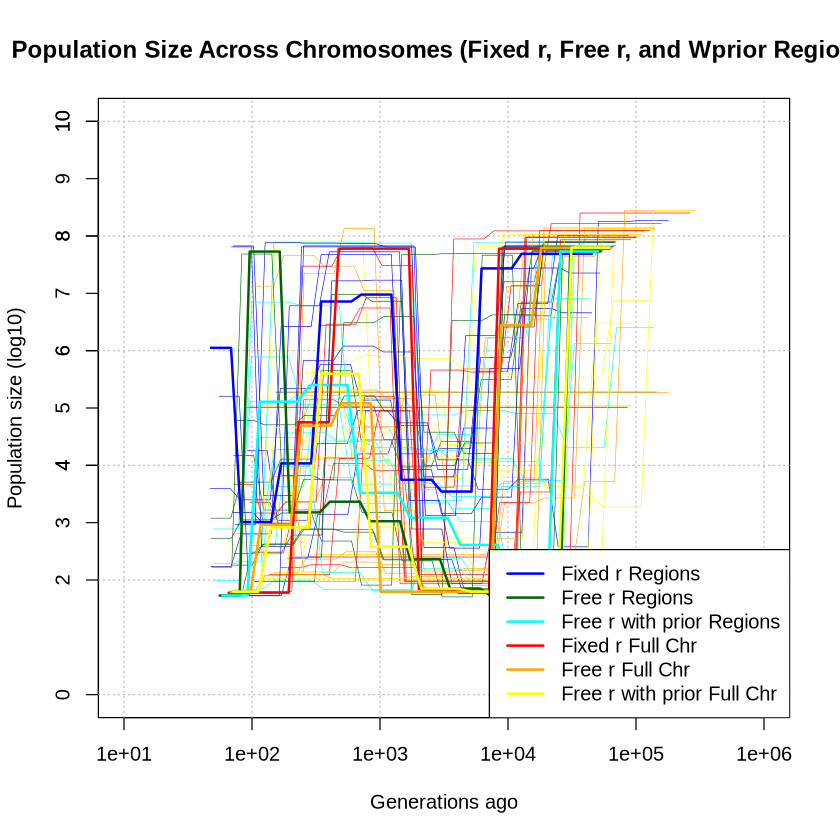

In [ ]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(0, 10), 
     xlim = c(10, 10^6), 
     type = "n", 
     xlab = "Generations ago", 
     ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes (Fixed r, Free r, and Wprior Regions)")

# Define y-axis ticks (optional, if you need customization)
y_ticks <- seq(3, 10, by = 1)  # Steps of 1
axis(2, at = y_ticks, labels = y_ticks)  # Add custom y-axis ticks

# Add grid lines for better visualization
grid(nx = NULL, ny = NULL, col = "gray", lty = "dotted")

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {

  # Skip 14 as it will be plotted separately
  if (chr != "allchr") {

    # Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "blue", lwd = 0.5)  # Blue for Fixed_r Regions
    }

    # Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$mu / mu)  # Fixed mu for Free_r Regions
      lines(plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Dark green for Free_r Regions
    }

    # Free_r with prior Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$mu / mu)  # Fixed mu for Free_r with prior
      lines(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "cyan", lwd = 0.5)  # Cyan for Free_r with prior Regions
    }

    # Fixed_r Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$mu / mu)  # Fixed mu for Fixed_r Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "red", lwd = 0.5)  # Red for Fixed_r Full Chr
    }

    # Free_r Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "orange", lwd = 0.5)  # Orange for Free_r Full Chr
    }

    # Free_r with prior Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$mu / mu)  # Fixed mu for Free_r with prior Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "yellow", lwd = 0.5)  # Yellow for Free_r with prior Full Chr
    }
  }
}

# Plot "All Chromosome" lines in bold
# Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']]) &&
    length(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "blue", lwd = 2)
}

# Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_regions_free_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Free_r with prior Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']]) &&
    length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "cyan", lwd = 2)
}

# Fixed_r Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# Free_r Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "orange", lwd = 2)
}

# Free_r with prior Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "yellow", lwd = 2)
}

# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Regions", "Free r Regions", "Free r with prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr", "Free r with prior Full Chr"),
       col = c("blue", "darkgreen", "cyan", "red", "orange", "yellow"), 
       lty = 1, lwd = 2)


In [ ]:
 if (!is.null(data_list[['14']]) && length(data_list[['14']]) > 0) {
    Ne_t <- data_list[['14']]$Xi
    Ne <- mean(data_list[['14']]$mu / mu)
    lines(data_list[['14']]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 2)
  }

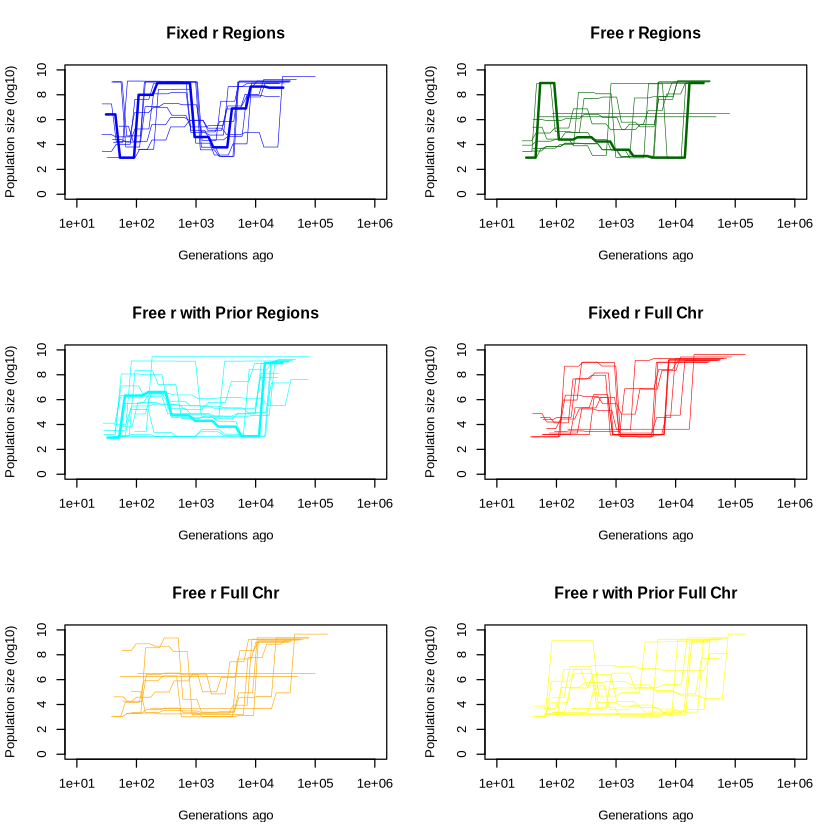

In [ ]:
# Set mutation rate and generation time
mu <- 2.45e-10  # Default mutation rate
gen <- 0.0054   # Generation time

# Set plot layout: 3 rows, 2 columns
par(bg = "white", mfrow = c(3, 2))  

# Function to plot regions data
plot_regions <- function(title, data_list, col) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- data_list[[chr]][[1]]$Xi
      Ne <- mean(data_list[[chr]][[1]]$mu / mu)
      lines(data_list[[chr]][[1]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 0.5)
    }
  }
  
  if (!is.null(data_list[['14']]) && length(data_list[['14']]) > 0) {
    Ne_t <- data_list[['14']][[1]]$Xi
    Ne <- mean(data_list[['14']][[1]]$mu / mu)
    lines(data_list[['14']][[1]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 2)
  }
}

# Function to plot full chromosome data
plot_full_chr <- function(title, data_list, col) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- data_list[[chr]]$Xi
      Ne <- mean(data_list[[chr]]$mu / mu)
      lines(data_list[[chr]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 0.5)
    }
  }
  
 
}

# Plot each data set in separate panels
plot_regions("Fixed r Regions", plot_data_list_newhetfile_smbc_regions_fixed_r, "blue")
plot_regions("Free r Regions", plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen")
plot_regions("Free r with Prior Regions", plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan")
plot_full_chr("Fixed r Full Chr", plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red")
plot_full_chr("Free r Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r, "orange")
plot_full_chr("Free r with Prior Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow")

# Reset layout
par(mfrow = c(1, 1))


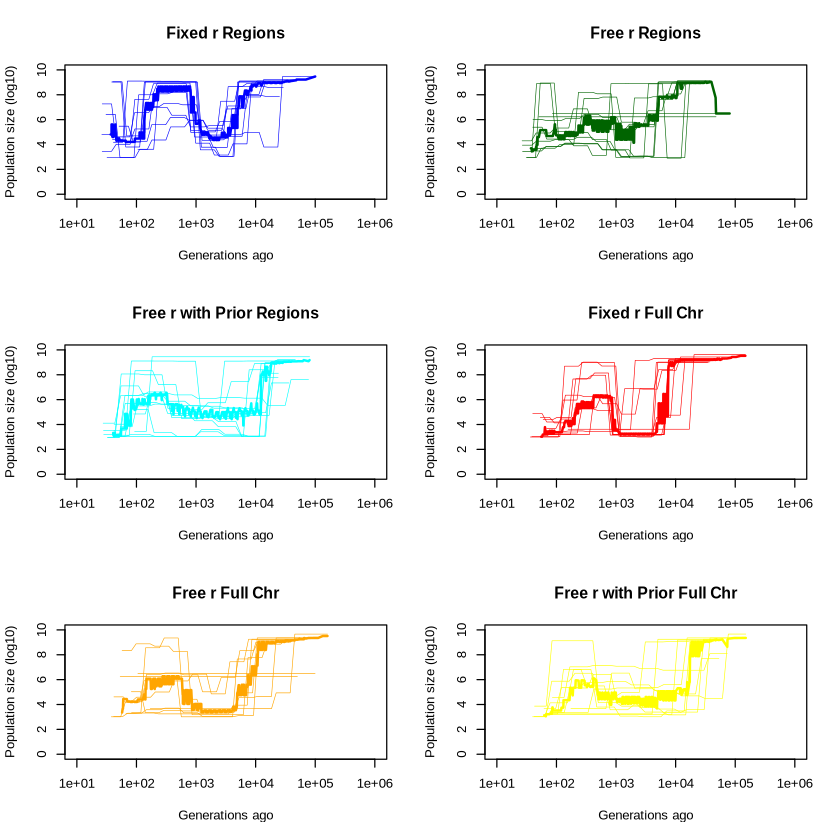

In [ ]:

# Set plot layout: 3 rows, 2 columns
par(bg = "white", mfrow = c(3, 2))  

# Function to calculate and plot rolling average
plot_with_rolling_avg <- function(title, data_list, col, is_region = TRUE) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store lines data for rolling average calculation
      all_lines <- append(all_lines, list(data.frame(generations, population)))
      
      lines(generations, population, col = col, lwd = 0.5)
    }
  }
  
  # Calculate rolling average if there are any lines
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]  # Remove duplicate x-values
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = median, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)  # Ensure lengths match
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    lines(roll_gen, roll_pop, col = col, lwd = 2)
  }
}

# Plot each data set with rolling average
plot_with_rolling_avg("Fixed r Regions", plot_data_list_newhetfile_smbc_regions_fixed_r, "blue", is_region = TRUE)
plot_with_rolling_avg("Free r Regions", plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen", is_region = TRUE)
plot_with_rolling_avg("Free r with Prior Regions", plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_rolling_avg("Fixed r Full Chr", plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_rolling_avg("Free r Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r, "orange", is_region = FALSE)
plot_with_rolling_avg("Free r with Prior Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Reset layout
par(mfrow = c(1, 1))


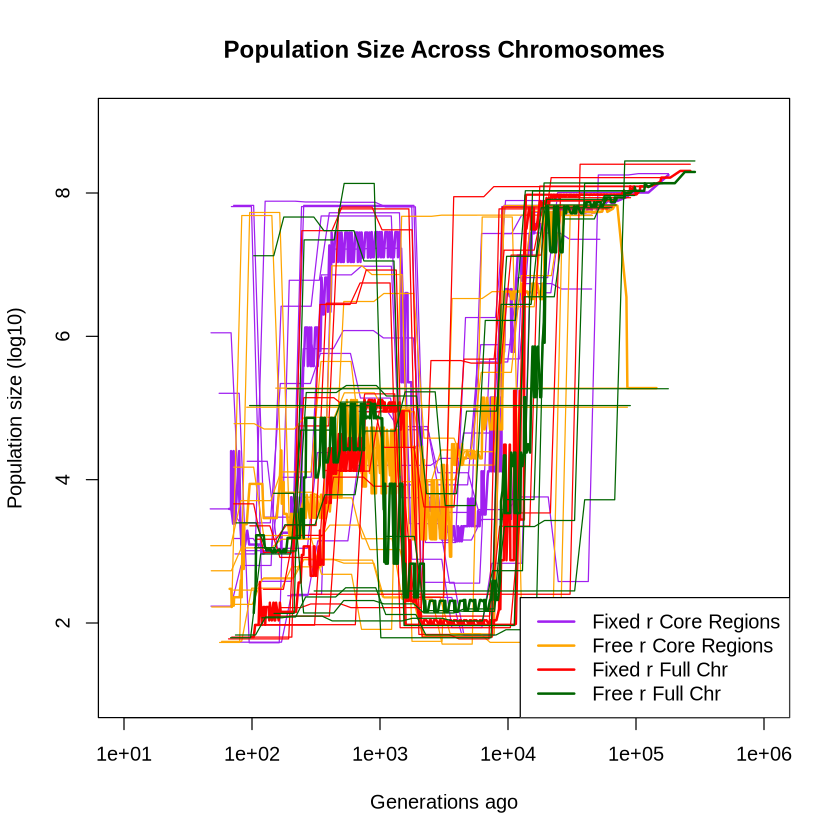

In [ ]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

# Set up single plot area with logarithmic x-axis
par(bg = "white")
plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(1, 9), xlim = c(10, 10^6), 
     type = "n", xlab = "Generations ago", ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes")

# Function to plot with rolling average
plot_with_rolling_avg <- function(data_list, col, is_region = TRUE) {
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store for rolling average
      all_lines <- append(all_lines, list(data.frame(generations, population)))
      
      lines(generations, population, col = col, lwd = 1)
    }
  }
  
  # Rolling average
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = median, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    lines(roll_gen, roll_pop, col = col, lwd = 2)
  }
}

# Plot each data set on the same plot
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_fixed_r, "purple", is_region = TRUE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_free_r, "orange", is_region = TRUE)
#plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_free_r, "darkgreen", is_region = FALSE)
#plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Core Regions", "Free r Core Regions", #"Free r w Molc-prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr"),#, "Free r w Molc-prior Full Chr"),
       col = c("purple", "orange", "red", "darkgreen"), 
       lty = 1, lwd = 2)



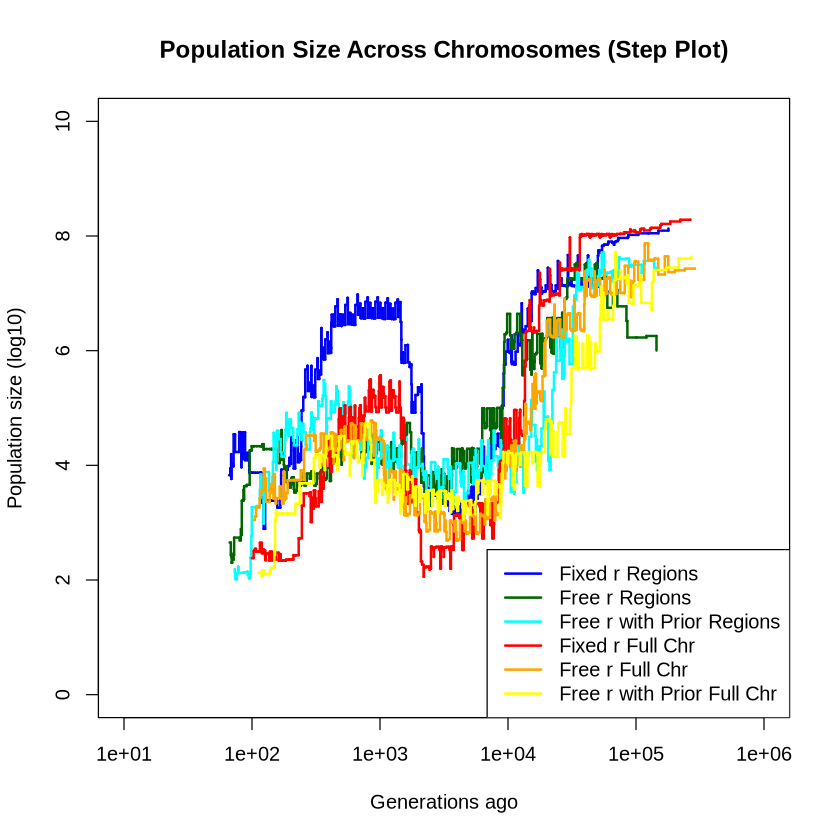

In [ ]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

# Set up a single plot with logarithmic x-axis
par(bg = "white")
plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
     type = "n", xlab = "Generations ago", ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes (Step Plot)")

# Function to plot using step-like lines (no points)
plot_with_step_and_avg <- function(data_list, col, is_region = TRUE) {
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store for rolling average calculation
      all_lines <- append(all_lines, list(data.frame(generations, population)))
    
    }
  }
  
  # Rolling average
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = mean, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    # Plot rolling average as step-like lines
    for (i in 1:(length(roll_gen) - 1)) {
      segments(x0 = roll_gen[i], y0 = roll_pop[i], x1 = roll_gen[i + 1], y1 = roll_pop[i], col = col, lwd = 2)
      segments(x0 = roll_gen[i + 1], y0 = roll_pop[i], x1 = roll_gen[i + 1], y1 = roll_pop[i + 1], col = col, lwd = 2)
    }
  }
}

# Plot each dataset using step-like lines
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_fixed_r, "blue", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_free_r, "orange", is_region = FALSE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Add legend
legend("bottomright", 
       legend = c("Fixed r Regions", "Free r Regions", "Free r with Prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr", "Free r with Prior Full Chr"),
       col = c("blue", "darkgreen", "cyan", "red", "orange", "yellow"), 
       lty = 1, lwd = 2)



In [ ]:
# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Core Regions", "Free r Core Regions", "Free r w Molc-prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr", "Free r w Molc-prior Full Chr"),
       col = c("blue", "darkgreen", "cyan", "red", "orange", "yellow"), 
       lty = 1, lwd = 2)

In [ ]:
names(plot_data_list_newhetfile_smbc_regions)[9:14]

ERROR: Error: object 'plot_data_list_newhetfile_smbc_regions' not found


In [3]:
# Initialize empty vectors for alpha and rho/mu values
rho_values <- c()
alpha_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (e.g., Free_r Regions, Free_r Full)

for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            # Append data to the vectors

            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)  # Add chromosome name
            category_labels <- c(category_labels, rep("Fixed r Core Regions", length(chr_data$rho)))
        }
    }
}

# Loop through Free_r Full data
for (chr in c(names(plot_data_list_newhetfile_smbc_regions_free_r))) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Core Regions", length(chr_data$rho)))
        }
    }
}

# Loop through Free_r Full data
for (chr in c(names(plot_data_list_newhetfile_smbc_regions_free_r_wprior))) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Molecular-prior Core Regions", length(chr_data$rho)))
        }
    }
}

#category_labels <- c(category_labels, rep("Free r Regions", 14))

# Loop through Fixed_r data
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_fixed_r))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Fixed r Full Chr", length(chr_data$rho)))
        }
    }
}
#category_labels <- c(category_labels, rep("Fixed r Full Chr", 13))

# Loop through Fixed_r Free data
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_free_r))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Full Chr", length(chr_data$rho)))
        }
    }
}
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Molecular-prior Full Chr", length(chr_data$rho)))
        }
    }
}
#category_labels <- c(category_labels, rep("Free r Full Chr", 13))

# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes=chromosomes,
    Rho = rho_values,
    Alpha = alpha_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = category_labels
)

boxplot_data


chromosomes,Rho,Alpha,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<chr>
04,0.0075283559,1.30,10.000000,Fixed r Core Regions
05,0.0021501677,1.65,10.000000,Fixed r Core Regions
06,0.0021824016,1.20,10.000000,Fixed r Core Regions
07,0.0041048844,1.60,10.000000,Fixed r Core Regions
08,0.0031245962,1.55,10.000000,Fixed r Core Regions
09,0.0027181654,1.20,10.000000,Fixed r Core Regions
10,0.0031735782,1.50,10.000000,Fixed r Core Regions
11,0.0026138190,1.20,10.000000,Fixed r Core Regions
12,0.0019331921,1.35,10.000000,Fixed r Core Regions


In [ ]:
unique(boxplot_data$Category)


boxplot_data$Category <- as.character(boxplot_data$Category)


[1] "Fixed r Core Regions"                "Free r Core Regions"                
[3] "Free r Molecular-prior Core Regions" "Fixed r Full Chr"                   
[5] "Free r Full Chr"                     "Free r Molecular-prior Full Chr"

In [4]:


boxplot_data<-boxplot_data %>% 
    filter(!grepl("Molecular-prior", Category))
boxplot_data
str(boxplot_data)

chromosomes,Rho,Alpha,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<chr>
04,7.528356e-03,1.30,10.00000000,Fixed r Core Regions
05,2.150168e-03,1.65,10.00000000,Fixed r Core Regions
06,2.182402e-03,1.20,10.00000000,Fixed r Core Regions
07,4.104884e-03,1.60,10.00000000,Fixed r Core Regions
08,3.124596e-03,1.55,10.00000000,Fixed r Core Regions
09,2.718165e-03,1.20,10.00000000,Fixed r Core Regions
10,3.173578e-03,1.50,10.00000000,Fixed r Core Regions
11,2.613819e-03,1.20,10.00000000,Fixed r Core Regions
12,1.933192e-03,1.35,10.00000000,Fixed r Core Regions


'data.frame':	44 obs. of  5 variables:
 $ chromosomes : chr  "04" "05" "06" "07" ...
 $ Rho         : num  0.00753 0.00215 0.00218 0.0041 0.00312 ...
 $ Alpha       : num  1.3 1.65 1.2 1.6 1.55 1.2 1.5 1.2 1.35 1.4 ...
 $ Rho_Mu_Ratio: num  10 10 10 10 10 10 10 10 10 10 ...
 $ Category    : chr  "Fixed r Core Regions" "Fixed r Core Regions" "Fixed r Core Regions" "Fixed r Core Regions" ...


In [ ]:
boxplot_data$Category <- factor(boxplot_data$Category)


print(levels(boxplot_data$Category))

[1] "Fixed r Core Regions" "Fixed r Full Chr"     "Free r Core Regions" 
[4] "Free r Full Chr"     


In [5]:
medians_alpha <- boxplot_data %>%
  filter(!chromosomes %in% c("01", "02", "03", "04")) %>%  # Remove rows with chromosomes 01 to 04
  group_by(Category) %>%
  summarise(Median_Alpha = median(Alpha, na.rm = TRUE))

medians_alpha

Category,Median_Alpha
<chr>,<dbl>
Fixed r Core Regions,1.375
Fixed r Full Chr,1.150
Free r Core Regions,1.375
Free r Full Chr,1.175


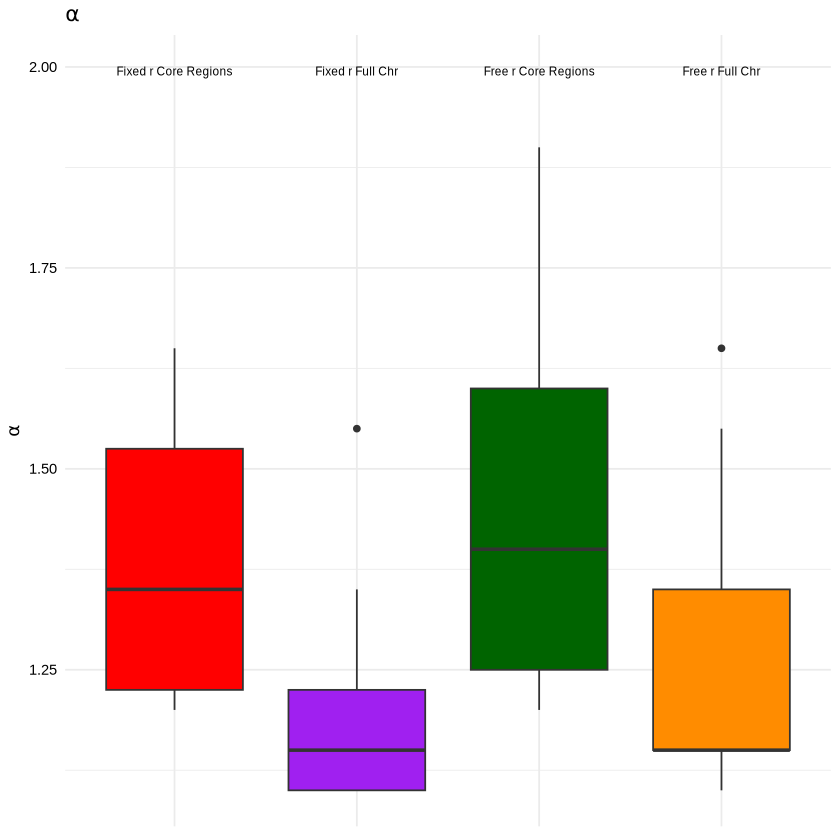

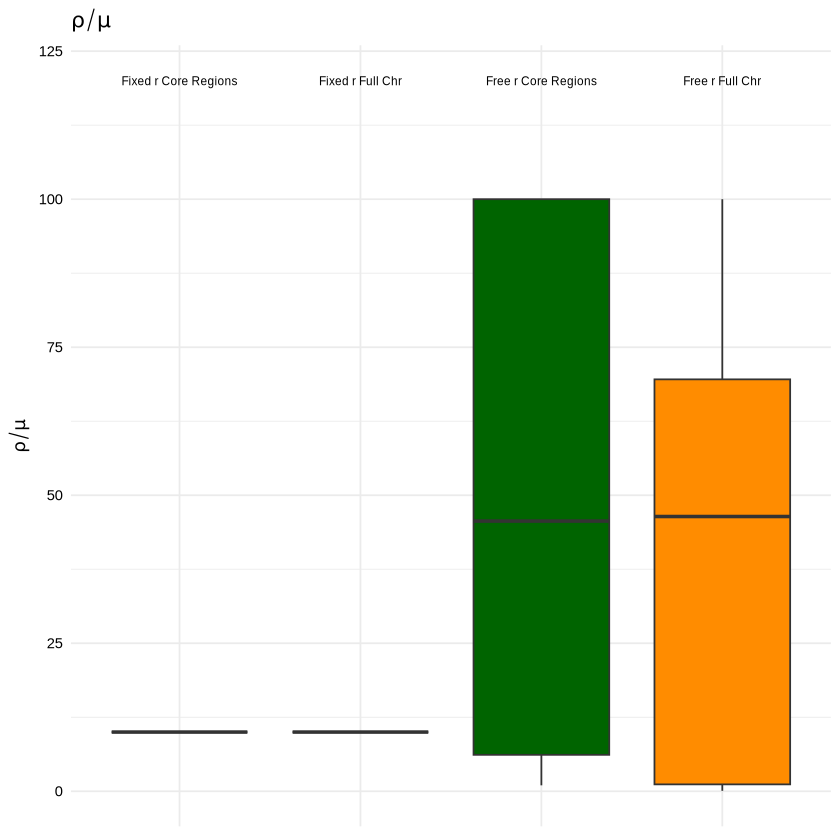

In [ ]:
# Boxplot for Alpha
plot_alpha <- ggplot(boxplot_data, aes(x = Category, y = Alpha, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(alpha), y = expression(alpha)) +
    scale_fill_manual(values = c("red", "purple", "darkgreen", "darkorange","blue","yellow"), name = "Category") +
    theme_minimal() +
    theme(
        legend.position = "none", # Remove legend
        axis.text.x = element_blank(), # Remove x-axis text
        axis.title.x = element_blank(),
        axis.text = element_text(color = "black"),
        axis.title = element_text(color = "black"),
        plot.title = element_text(color = "black")
    ) +
    annotate("text", x = 1:4, y = max(boxplot_data$Alpha, na.rm = TRUE) * 1.05, # Position above boxplots
             label = levels(boxplot_data$Category), size = 2.5, color = "black") # Add labels

plot_alpha

# Boxplot for Rho/Mu
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(rho / mu), y = expression(rho / mu)) +
    scale_fill_manual(values = c("red", "purple", "darkgreen", "darkorange","blue","yellow"), name = "Category") +
    theme_minimal() +
    theme(
        legend.position = "none", # Remove legend
        axis.text.x = element_blank(), # Remove x-axis text
        axis.title.x = element_blank(),
        axis.text = element_text(color = "black"),
        axis.title = element_text(color = "black"),
        plot.title = element_text(color = "black")
    ) +
    
    annotate("text", x = 1:4, y = max(boxplot_data$Rho_Mu_Ratio, na.rm = TRUE) * 1.2, # Position above boxplots
             label = levels(boxplot_data$Category), size = 2.5, color = "black") # Add labels

plot_rho_mu


In [ ]:
names(plot_data_list_newhetfile_smbc_full_chr_free_r)

[1] "01" "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14"

In [ ]:
tail(names(plot_data_list_newhetfile_smbc_full_chr), 5)

ERROR: Error: object 'plot_data_list_newhetfile_smbc_full_chr' not found


In [6]:
# Initialize an empty list to collect data for all datasets
dot_plot_data <- data.frame()

# Loop through the last 5 chromosomes for each plot dataset

# 1. Fixed r Regions
for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Fixed r Core Regions"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 2. Free r Regions
for (chr in names(plot_data_list_newhetfile_smbc_regions_free_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Core Regions"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

for (chr in names(plot_data_list_newhetfile_smbc_regions_free_r_wprior)) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Core Regions w Molecular-prior"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 3. Fixed r Full Chr
for (chr in names(plot_data_list_newhetfile_smbc_full_chr_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Fixed r Full Chr"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 4. Free r Full Chr
for (chr in names(plot_data_list_newhetfile_smbc_full_chr_free_r)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Full Chr"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

for (chr in names(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Full Chr w Molecular-prior"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

dot_plot_data

Chromosome,Alpha,Dataset
<chr>,<dbl>,<chr>
04,1.30,Fixed r Core Regions
05,1.65,Fixed r Core Regions
06,1.20,Fixed r Core Regions
07,1.60,Fixed r Core Regions
08,1.55,Fixed r Core Regions
09,1.20,Fixed r Core Regions
10,1.50,Fixed r Core Regions
11,1.20,Fixed r Core Regions
12,1.35,Fixed r Core Regions


In [11]:
# Assuming your data is in a data frame called df
free_core <- subset(dot_plot_data, Dataset == "Free r Core Regions")

# Save to CSV
write.table(free_core, "Free_r_Core_Regions_ms.csv", row.names = FALSE, sep = "\t", quote = FALSE)


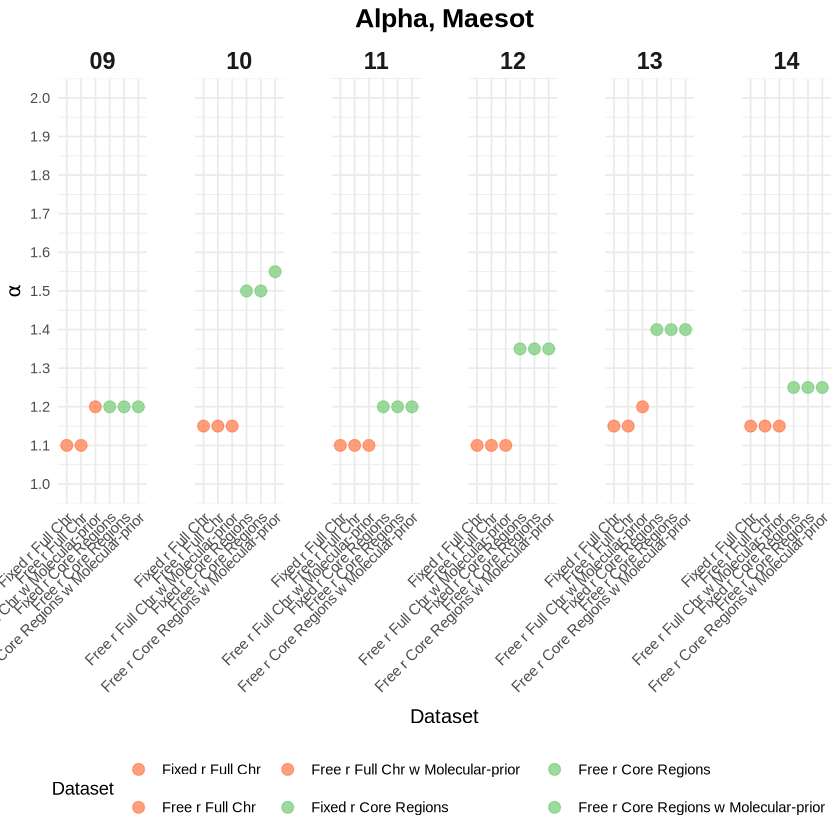

In [ ]:
# Define custom colors for each Dataset
custom_colors <- c(
    "Fixed r Full Chr" = "coral",      # Coral (red)
    "Free r Full Chr" = "coral",       # Coral (orange)
    "Free r Full Chr w Molecular-prior" = "coral", # Blue
    "Fixed r Core Regions" = "palegreen3",  # Light green
    "Free r Core Regions" = "palegreen3",   # Light green
    "Free r Core Regions w Molecular-prior" = "palegreen3"  # Blue
)

# Ensure that the 'Dataset' column is a factor with correct levels corresponding to custom colors
dot_plot_data$Dataset <- factor(dot_plot_data$Dataset, levels = names(custom_colors))

# Filter data to only include chromosomes 09 to 14
chromosomes_09_to_14 <- c("09", "10", "11", "12", "13", "14")
filtered_data <- dot_plot_data[dot_plot_data$Chromosome %in% chromosomes_09_to_14, ]

# Dot plot with facet_wrap by Chromosome (only showing chromosomes 09 to 14)
dot_plot <- ggplot(filtered_data, aes(x = Dataset, y = Alpha, color = Dataset)) +
    geom_point(
               size = 3, 
               alpha = 0.75) +  # Add jitter for better visibility
    labs(
        title = "Alpha, Maesot",
        x = "Dataset",
        y = expression(alpha)
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
        strip.text = element_text(size = 14, face = "bold"),
        legend.position = "bottom",
        panel.spacing = unit(2, "lines")  # Increase space between facets
    ) +
    facet_wrap(~Chromosome, ncol = 6) +  # Facet by Chromosome, 6 columns
    scale_y_continuous(limits = c(1, 2), breaks = seq(1, 2, by = 0.1)) +  # Set y-axis limits and breaks
    scale_color_manual(values = custom_colors)  # Set custom colors

# Display the plot
print(dot_plot)


In [ ]:
# Define custom colors for each Dataset
custom_colors <- c(
"Fixed r Full Chr" = "coral",      # Coral (red)
    "Free r Full Chr" = "coral",       # Coral (orange)
    "Free r Full Chr w Molecular-prior" = "coral", # Blue
    "Fixed r Core Regions" = "palegreen3",  # Light green
    "Free r Core Regions" = "palegreen3",   # Light green
    "Free r Core Regions w Molecular-prior" = "palegreen3"  # Blue
)
# Create a coded version for x-axis (coded labels)
#coded_labels <- c("FRC", "FRCwP", "FFC", "FFCR", "FRRwP", "FRR")

# Create a simplified version for the x-axis (coded labels)
#dot_plot_data$SimplifiedDataset <- factor(dot_plot_data$Dataset, 
#                                          levels = names(custom_colors),
#                                          labels = coded_labels)
#
# Ensure that the 'Dataset' column is a factor with correct levels corresponding to custom colors
dot_plot_data$Dataset <- factor(dot_plot_data$Dataset, levels = names(custom_colors))

# Filter data to only include chromosomes 09 to 14
chromosomes_09_to_14 <- c("09", "10", "11", "12", "13", "14")
filtered_data <- dot_plot_data[dot_plot_data$Chromosome %in% chromosomes_09_to_14, ]




In [ ]:
dot_plot_data

Chromosome,Alpha,Dataset
<chr>,<dbl>,<fct>
04,1.30,Fixed r Core Regions
05,1.65,Fixed r Core Regions
06,1.20,Fixed r Core Regions
07,1.60,Fixed r Core Regions
08,1.55,Fixed r Core Regions
09,1.20,Fixed r Core Regions
10,1.50,Fixed r Core Regions
11,1.20,Fixed r Core Regions
12,1.35,Fixed r Core Regions


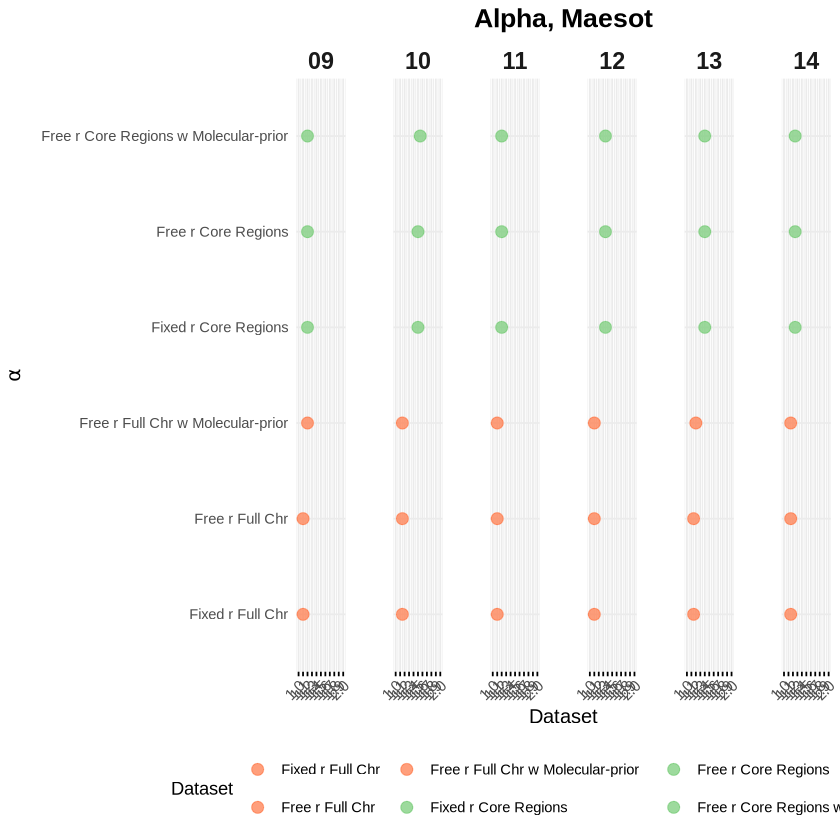

In [ ]:
dot_plot <- ggplot(filtered_data, aes(x = Alpha, y = Dataset, color = Dataset)) +
    geom_point(size = 3, 
               alpha = 0.75) +  # Add jitter for better visibility
    labs(
        title = "Alpha, Maesot",
        x = "Dataset",
        y = expression(alpha)
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
        axis.ticks.x = element_line(),  # Add x-axis ticks
        strip.text = element_text(size = 14, face = "bold"),
        legend.position = "bottom",
        panel.spacing = unit(2, "lines")  # Increase space between facets
    ) +
    facet_wrap(~Chromosome, ncol=7) +  # Facet by Chromosome, 6 columns
    scale_x_continuous(limits = c(1, 2), breaks = seq(1, 2, by = 0.1)) +  # Set y-axis limits and breaks
    scale_color_manual(values = custom_colors)  # Set custom colors

# Display the plot
print(dot_plot)


In [ ]:
png_file_path <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/plot_SMBC/ms_dot_plot.png"

# Save the plot as a PNG
ggsave(png_file_path, plot = dot_plot, width = 25, height = 8, dpi = 300)


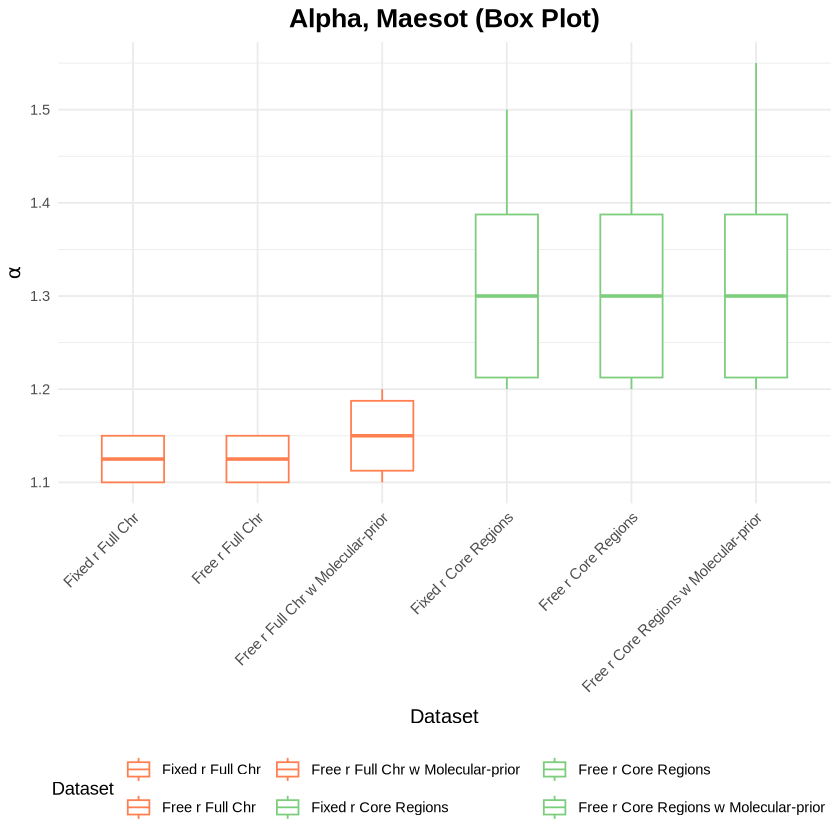

In [ ]:
# Box plot for better visualization of data distribution
box_plot <- ggplot(filtered_data, aes(x = Dataset, y = Alpha, color = Dataset)) +
    geom_boxplot(outlier.size = 2, width = 0.5) +
    labs(
        title = "Alpha, Maesot (Box Plot)",
        x = "Dataset",
        y = expression(alpha)
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 14, face = "bold"),
        legend.position = "bottom",
        panel.spacing = unit(2, "lines")
    ) +
    scale_color_manual(values = custom_colors)  # Set custom colors

# Display the box plot
print(box_plot)


In [ ]:

# Reshape the data into long format if needed
heatmap_data <- melt(dot_plot_data)


Using Chromosome, Dataset as id variables



In [ ]:
heatmap_data <- heatmap_data %>% 
    filter(variable == "Alpha" & !grepl("w Molecular-prior", Dataset))

# Display the filtered data
heatmap_data[,"value"]<-as.numeric(heatmap_data[,"value"])


names(heatmap_data)<-c("Chromosome","Dataset","variable","Alpha")
str(heatmap_data)

'data.frame':	44 obs. of  4 variables:
 $ Chromosome: chr  "04" "05" "06" "07" ...
 $ Dataset   : Factor w/ 6 levels "Fixed r Full Chr",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ variable  : Factor w/ 1 level "Alpha": 1 1 1 1 1 1 1 1 1 1 ...
 $ Alpha     : num  1.3 1.65 1.2 1.6 1.55 1.2 1.5 1.2 1.35 1.4 ...


In [ ]:
str(heatmap_data)

'data.frame':	56 obs. of  4 variables:
 $ Chromosome: chr  "01" "02" "03" "04" ...
 $ Dataset   : Factor w/ 6 levels "Fixed r Full Chr",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ variable  : Factor w/ 1 level "Alpha": 1 1 1 1 1 1 1 1 1 1 ...
 $ Alpha     : num  1.5 1.35 1.1 1.3 1.65 1.2 1.6 1.55 1.2 1.5 ...


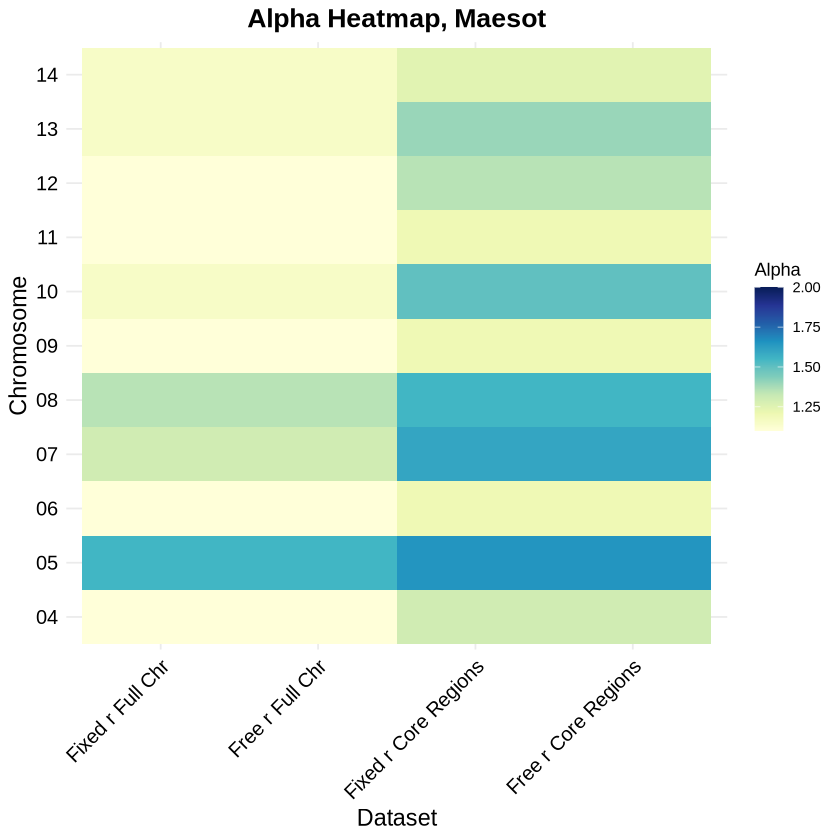

In [ ]:
# Heatmap visualization
heatmap_plot <- ggplot(heatmap_data, aes(x = Dataset, y = Chromosome, fill = Alpha)) +
    geom_tile() +
    scale_fill_gradientn(
        colors = brewer.pal(9, "YlGnBu"),  # Color palette
        limits = c(1.1, 2)  # Setting the range for the gradient
    ) +
    labs(title = "Alpha Heatmap, Maesot", x = "Dataset", y = "Chromosome") +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),  # Make y-axis tick labels black
        strip.text = element_text(size = 16, face = "bold", color = "black")
    )

# Display the heatmap
print(heatmap_plot)


In [ ]:
# Define the file paths
pdf_file_path <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/plot_SMBC/ms_dot_plot.pdf"
png_file_path <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/plot_SMBC/ms_dot_plot.png"

# Save the plot as a PDF
ggsave(pdf_file_path, plot = dot_plot, width = 20, height = 8)

# Save the plot as a PNG
ggsave(png_file_path, plot = dot_plot, width = 20, height = 8, dpi = 300)


In [ ]:
rho_mu<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/scripts_msmc_esmc/plot_esmc_msmc/boxplot_free_r.txt", sep='\t', header=T)
rho_mu<-rho_mu %>% mutate(chromosomes = as.character(as.numeric(chromosomes))) %>% na.omit()

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chromosomes = as.character(as.numeric(chromosomes))`.
Caused by warning:
! NAs introduced by coercion”


In [ ]:
boxplot_free_r <- dot_plot_data %>% 
  mutate(Dataset = recode(Dataset, "Free r Full Chr" = "Free r Full Chromosome")) %>% 
  filter(Dataset == "Free r Full Chromosome" | Dataset == "Free r Core Regions") %>%
  mutate(Chromosome = as.character(as.numeric(Chromosome)))
boxplot_free_r

Chromosome,Alpha,Dataset
<chr>,<dbl>,<fct>
4,1.30,Free r Core Regions
5,1.65,Free r Core Regions
6,1.20,Free r Core Regions
7,1.60,Free r Core Regions
8,1.55,Free r Core Regions
9,1.20,Free r Core Regions
10,1.50,Free r Core Regions
11,1.20,Free r Core Regions
12,1.35,Free r Core Regions


In [ ]:


alpha_rho_mu<-left_join(boxplot_free_r,rho_mu, by = c("Dataset" = "Category", "Chromosome" = "chromosomes"))
alpha_rho_mu


Chromosome,Alpha,Dataset,Rho,Mu,Rho_Mu_Ratio
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
4,1.30,Free r Core Regions,0.009766473,0.0006027344,16.203609
5,1.65,Free r Core Regions,0.010178851,0.0002228908,45.667439
6,1.20,Free r Core Regions,0.006347756,0.0002158434,29.409084
7,1.60,Free r Core Regions,0.005680375,0.0003528587,16.098158
8,1.55,Free r Core Regions,0.004927400,0.0002907819,16.945347
9,1.20,Free r Core Regions,0.005080050,0.0002543364,19.973744
10,1.50,Free r Core Regions,0.005001539,0.0003125687,16.001407
11,1.20,Free r Core Regions,0.004231674,0.0002499212,16.932033
12,1.35,Free r Core Regions,0.014366063,0.0001932656,74.333282


Correlation table

In [ ]:
correlation_results <- alpha_rho_mu %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_lumped = cor(Alpha, Rho_Mu_Ratio, use = "complete.obs"),
  )

# Display the correlation results
print(correlation_results)

# A tibble: 2 × 2
  Dataset                corr_singleton_lumped
  <chr>                                  <dbl>
1 Free r Core Regions                   0.0855
2 Free r Full Chromosome                0.0684


In [ ]:
# Read the data (replace 'your_file.txt' with the actual file name)
data <- read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Div_Recomb_stats/MaeSot_sfs_full.txt", header = T ,sep="\t")
#data
# Extract rows 5 to 15 (adjust column indices as necessary)
subset_data <- data[,-c(1:2)]  # Exclude the first column if it's not part of the SFS



In [ ]:

# Convert to numeric matrix
emp_sfs <- as.matrix(subset_data)

# Define cutoff value
cutoff <-15# Adjust this as needed
n=89

rows_sums <- rowSums(emp_sfs[, cutoff:n])

results <- cbind(sprintf("%02d", 1:14),as.numeric(emp_sfs[,1]), as.numeric(rows_sums))
colnames(results)<-c("Chromosome","singleton","lumped_tail")
#Convert results to a data frame
results_df <- as.data.frame(results)

# Ensure that columns 2 and 3 are numeric
results_df$singleton <- as.numeric(results_df$singleton)
results_df$lumped_tail <- as.numeric(results_df$lumped_tail)

# Check the structure of the data frame to verify column types
results_df<-results_df[5:14,]


In [ ]:
# Join df1 and df2 by Chromosome
merged_df <- left_join(heatmap_data, results_df, by = "Chromosome")
merged_df<-na.omit(merged_df)
merged_df

,Chromosome,Dataset,variable,Alpha,singleton,lumped_tail
,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2,05,Fixed r Core Regions,Alpha,1.65,0.2457082,0.2317597
3,06,Fixed r Core Regions,Alpha,1.20,0.2141935,0.3161290
4,07,Fixed r Core Regions,Alpha,1.60,0.1873351,0.3755497
5,08,Fixed r Core Regions,Alpha,1.55,0.1997940,0.3388260
6,09,Fixed r Core Regions,Alpha,1.20,0.2073864,0.2518939
7,10,Fixed r Core Regions,Alpha,1.50,0.2281776,0.2297090
8,11,Fixed r Core Regions,Alpha,1.20,0.2339100,0.2000000
9,12,Fixed r Core Regions,Alpha,1.35,0.2441773,0.2051089
10,13,Fixed r Core Regions,Alpha,1.40,0.2171157,0.2023244


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


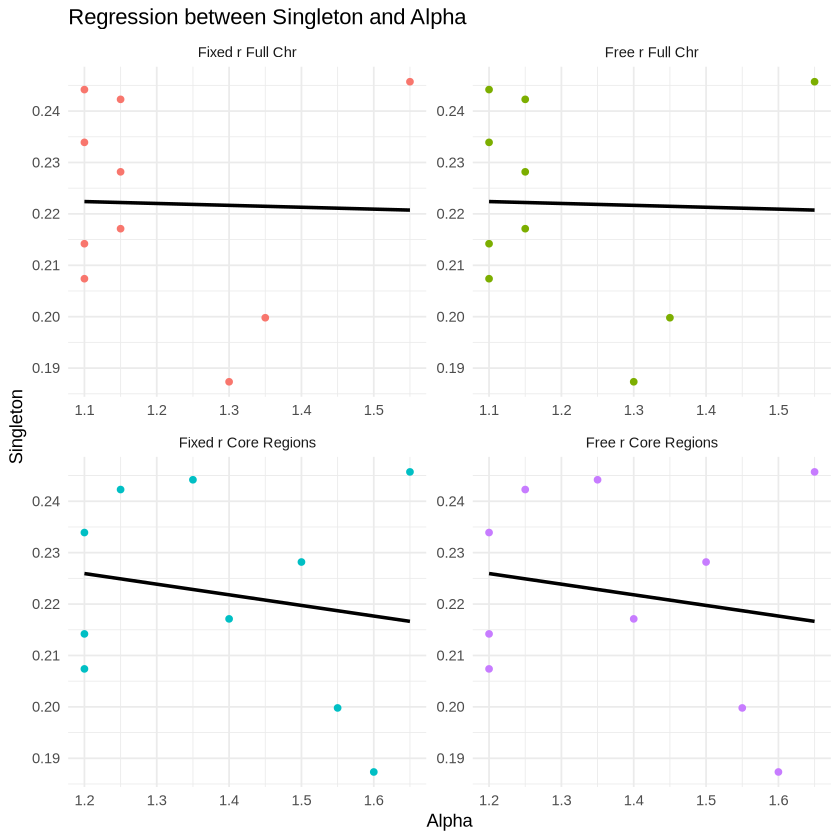

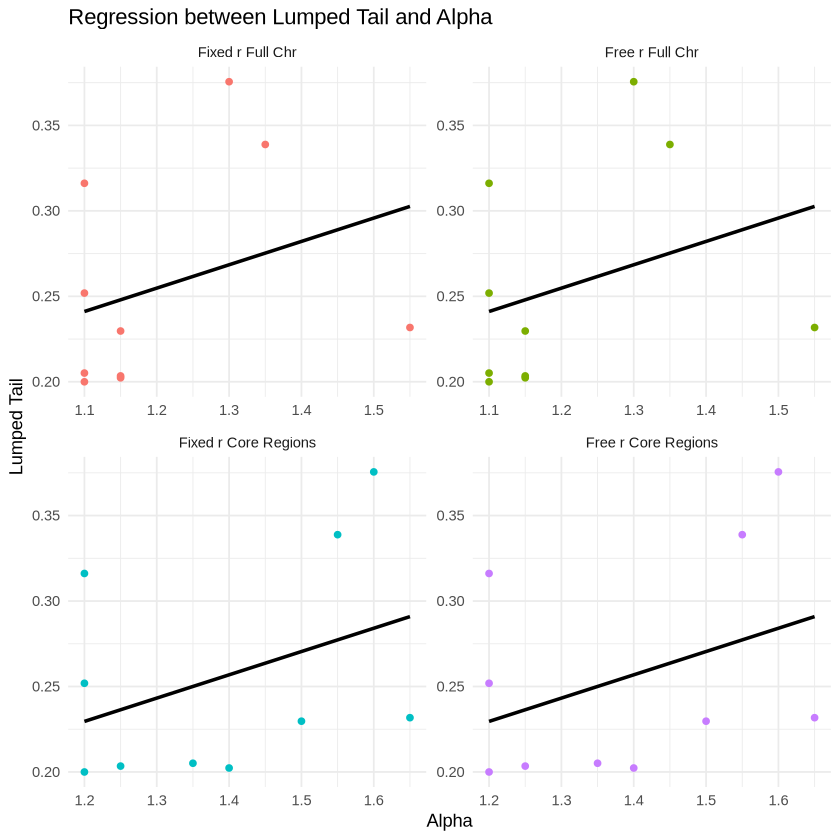

In [ ]:
# Fit regression models for each category
# Plot for Singleton vs Alpha for each Dataset
plot_singleton_alpha <- ggplot(merged_df, aes(x = Alpha, y = singleton, color = Dataset)) +
  geom_point() +  # Plot points
  geom_smooth(method = "lm", se = FALSE, aes(group = Dataset), color = "black") +  # Add regression line
  labs(title = "Regression between Singleton and Alpha", 
       x = "Alpha", 
       y = "Singleton") +
  theme_minimal() +
  theme(legend.position = "none") +  # Hide legend for clarity in each plot
  facet_wrap(~Dataset, scales = "free")  # Facet by Dataset

# Plot for Lumped Tail vs Alpha for each Dataset
plot_lumped_tail_alpha <- ggplot(merged_df, aes(x = Alpha, y = lumped_tail, color = Dataset)) +
  geom_point() +  # Plot points
  geom_smooth(method = "lm", se = FALSE, aes(group = Dataset), color = "black") +  # Add regression line
  labs(title = "Regression between Lumped Tail and Alpha", 
       x = "Alpha", 
       y = "Lumped Tail") +
  theme_minimal() +
  theme(legend.position = "none") +  # Hide legend for clarity in each plot
  facet_wrap(~Dataset, scales = "free")  # Facet by Dataset

# Print both plots
print(plot_singleton_alpha)
print(plot_lumped_tail_alpha)




In [ ]:
# Calculate slope (trend metric) and R² for each category and plot
regression_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    singleton_alpha_slope = coef(lm(singleton ~ Alpha))[2],  # Extract slope for singleton ~ Alpha
    lumped_tail_alpha_slope = coef(lm(lumped_tail ~ Alpha))[2],  # Extract slope for lumped_tail ~ Alpha
    singleton_alpha_r2 = summary(lm(singleton ~ Alpha))$r.squared,  # R² for singleton ~ Alpha
    lumped_tail_alpha_r2 = summary(lm(lumped_tail ~ Alpha))$r.squared  # R² for lumped_tail ~ Alpha
  )

# View the regression results including R²
print(as.data.frame(regression_results))


               Dataset singleton_alpha_slope lumped_tail_alpha_slope
1     Fixed r Full Chr          -0.003684336               0.1366332
2      Free r Full Chr          -0.003684336               0.1366332
3 Fixed r Core Regions          -0.020669357               0.1362570
4  Free r Core Regions          -0.020669357               0.1362570
  singleton_alpha_r2 lumped_tail_alpha_r2
1       0.0007546062            0.1008745
2       0.0007546062            0.1008745
3       0.0327620844            0.1383893
4       0.0327620844            0.1383893


In [ ]:
# Calculate correlation coefficients between Alpha and singleton, and Alpha and lumped_tail for each dataset
correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_alpha = cor(singleton, Alpha, use = "complete.obs"),
    corr_lumped_tail_alpha = cor(lumped_tail, Alpha, use = "complete.obs")
  )

# Display the correlation results
print(correlation_results)


# A tibble: 4 × 3
  Dataset              corr_singleton_alpha corr_lumped_tail_alpha
  <fct>                               <dbl>                  <dbl>
1 Fixed r Full Chr                  -0.0275                  0.318
2 Free r Full Chr                   -0.0275                  0.318
3 Fixed r Core Regions              -0.181                   0.372
4 Free r Core Regions               -0.181                   0.372


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


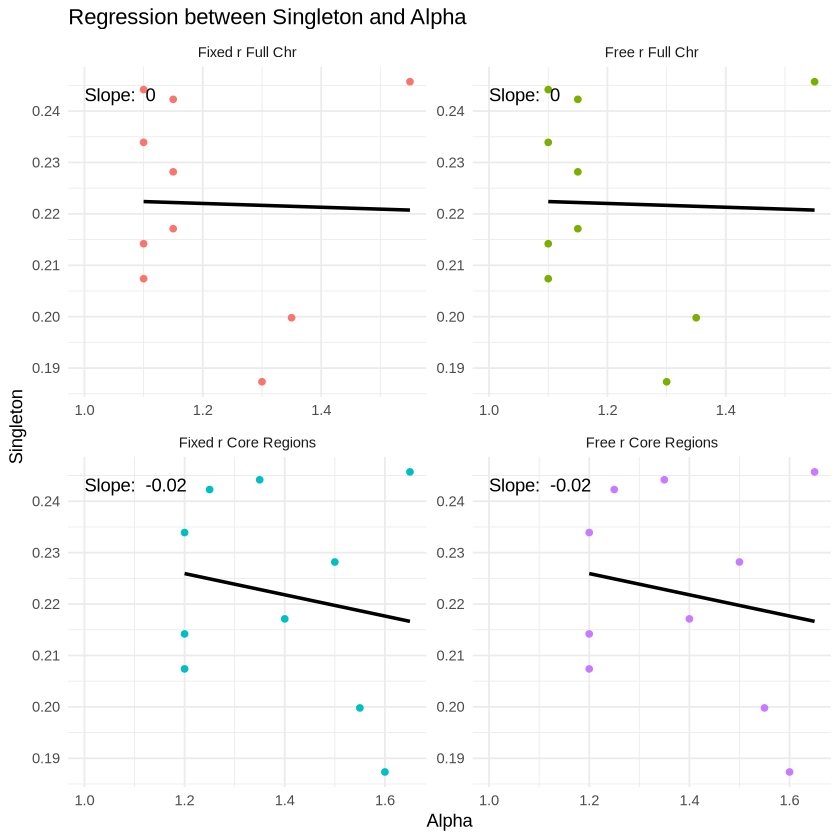

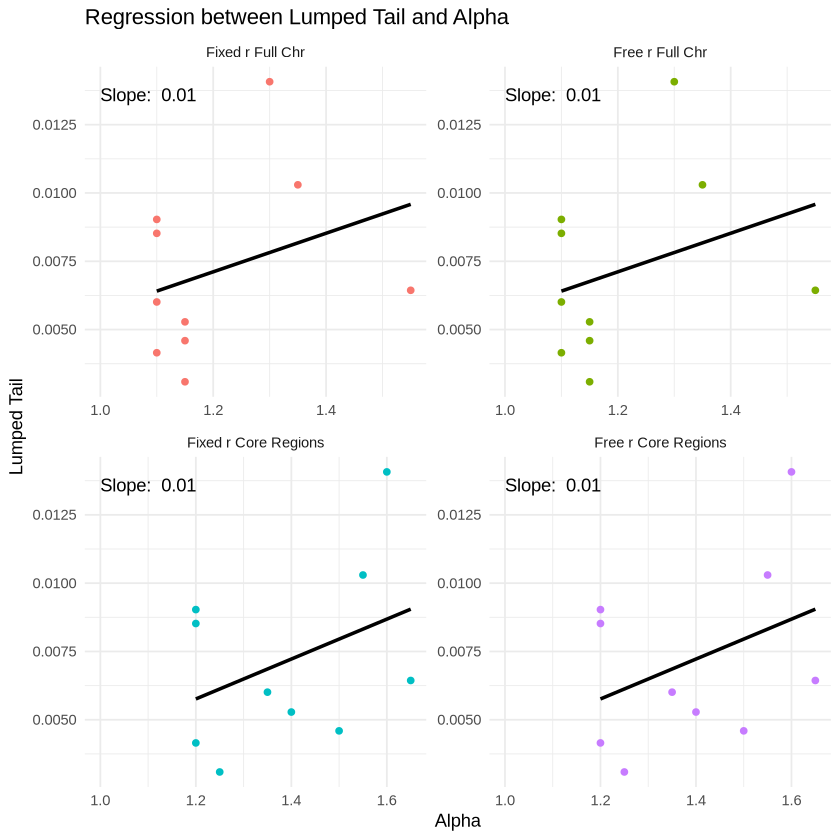

In [ ]:
# Optional: Add the slopes to the plots (for example, as labels or annotations)
plot_singleton_alpha <- plot_singleton_alpha + 
  geom_text(data = regression_results, aes(x = 1, y = max(merged_df$singleton), label = paste("Slope: ", round(singleton_alpha_slope, 2))), 
            color = "black", hjust = 0, vjust = 1.5)

plot_lumped_tail_alpha <- plot_lumped_tail_alpha + 
  geom_text(data = regression_results, aes(x = 1, y = max(merged_df$lumped_tail), label = paste("Slope: ", round(lumped_tail_alpha_slope, 2))), 
            color = "black", hjust = 0, vjust = 1.5)

# Print updated plots with slopes
print(plot_singleton_alpha)
print(plot_lumped_tail_alpha)

In [ ]:
merged_df

,Chromosome,Dataset,variable,Alpha,singleton,lumped_tail
,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2,05,Fixed r Core Regions,Alpha,1.65,0.2457082,0.2317597
3,06,Fixed r Core Regions,Alpha,1.20,0.2141935,0.3161290
4,07,Fixed r Core Regions,Alpha,1.60,0.1873351,0.3755497
5,08,Fixed r Core Regions,Alpha,1.55,0.1997940,0.3388260
6,09,Fixed r Core Regions,Alpha,1.20,0.2073864,0.2518939
7,10,Fixed r Core Regions,Alpha,1.50,0.2281776,0.2297090
8,11,Fixed r Core Regions,Alpha,1.20,0.2339100,0.2000000
9,12,Fixed r Core Regions,Alpha,1.35,0.2441773,0.2051089
10,13,Fixed r Core Regions,Alpha,1.40,0.2171157,0.2023244


In [ ]:
correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_lumped = cor(singleton, lumped_tail, use = "complete.obs"),
  )

# Display the correlation results
print(correlation_results)


# A tibble: 4 × 2
  Dataset              corr_singleton_lumped
  <fct>                                <dbl>
1 Fixed r Full Chr                    -0.834
2 Free r Full Chr                     -0.834
3 Fixed r Core Regions                -0.834
4 Free r Core Regions                 -0.834
